## Testing accuracy of quantics tensor trains for random functions

### Goal
Plot the accuracy against the maximal bond dimension of quantics tensor train approximations

### Method
Generate functions of predictable rank by generating random (normalized) Fourier coefficients, and imposing an exponential decay rate on those coefficients. Do this many times for each decay rate.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import xfacpy

In [2]:
def rand_func1d_sine_basis_idst(decay_rate, nBit, rng):
    '''
    Use the inverse discrete sine transform to generate a random function

    Args:
        decay_rate: Have sine series coefficients decay at rate n**(-decay_rate)
        nBit: Number of bits to represent a grid point, as in a quantics representation. Grid size is 2**nBit
        rng: Random number generator
    '''
    N = 2**nBit
    coeff = rng.uniform(-0.5, 0.5, N) * np.arange(1, N + 1, dtype=np.float64)**(-decay_rate)
    # normalize the total energy so that error analysis can be applied later
    coeff /= np.linalg.norm(coeff)
    
    # Perform inverse sine transform
    h = scipy.fft.idst(coeff, type=1, norm='ortho') * N

    return h

In [3]:
# Helper functions to make it so that we can use our generated function data with the xfac QTensor API.

def coord_to_decimal_index(x, lb=0, ub=1, nBit=10):
    # convert a real coordinate to an index into the array
    # WARNING: This needs some error handling and check against NaNs, 0s, etc.
    return int((x - lb) * (2**nBit / (ub - lb)))

def make_callable(f_, lb=0, ub=1, nBit=10):
    def f(x):
        return f_[coord_to_decimal_index(x, lb, ub, nBit)]
    return f

def reconstruct(qtci, xs):
    return np.array([qtci.get_qtt().eval([x]) for x in xs])

In [34]:
# Test runner function

def run_for_given_order(generator=rand_func1d_sine_basis_idst, order=0, bondDims=10, nRuns=100, nBit=10, rng=np.random.default_rng()):
    l2_error = np.zeros((nRuns, bondDims), dtype=np.float64)
    for bondDim in range(1, bondDims + 1):
        for run in range(nRuns):
            xs = np.linspace(0, 1, 2**nBit, endpoint=False)
            
            f_ = generator(order, nBit, rng)
            f = make_callable(f_)
            
            qgrid = xfacpy.QuanticsGrid(a=0.0, b=1.0, nBit=nBit)
            args = xfacpy.TensorCI2Param()
            args.bondDim = bondDim
            
            qtci = xfacpy.QTensorCI(f1d=f, qgrid=qgrid, args=args)
            
            while not (qtci.isDone()):
                qtci.iterate()
                
            f_qtt = reconstruct(qtci, xs)
            error = np.linalg.norm(f_qtt - f_)
            l2_error[run][bondDim-1] = error
            
    return l2_error

## Results

For decay rates $O(1), \dots, O(1/n^6)$, we display the $L^2$ error in the quantics tensor train reconstruction against the maximal number of bond dimensions. For each class of function, we display 3 plots. (1) The $L^2$ error against the bond dimension with outliers omitted, (2) the same but with only bond dimensions 2 - 20 displayed, (3) the same as (1) but with outliers shown. I chose to plot (2) for each example so that more detail is shown in the rate of decay of error.

### $O(1)$ decay, QTT resolution = $2^{10}$, 100 runs

In [5]:
labels = np.arange(1, 21)

In [6]:
order0_l2_error = run_for_given_order(order=0, bondDims=20)

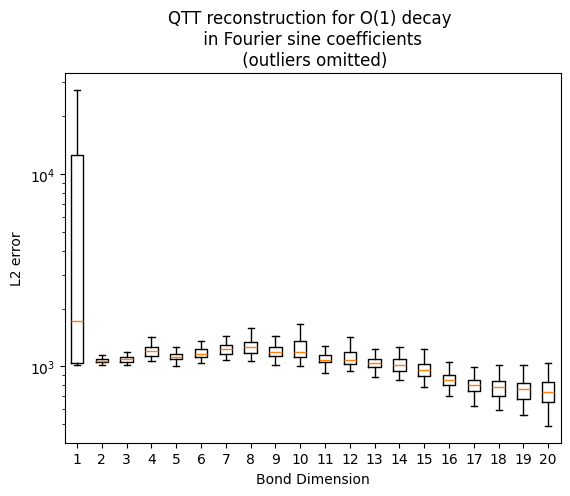

In [7]:
plt.boxplot(order0_l2_error, showfliers=False)
plt.title('QTT reconstruction for O(1) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

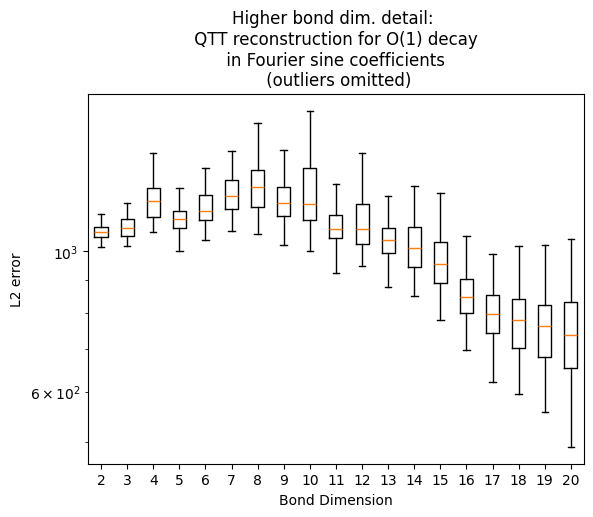

In [8]:
plt.boxplot(order0_l2_error[:,1:], tick_labels=labels[1:], showfliers=False)
plt.title('Higher bond dim. detail: \n QTT reconstruction for O(1) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

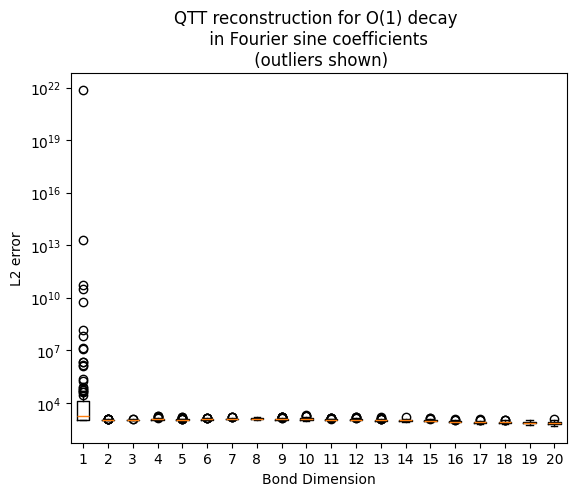

In [9]:
plt.boxplot(order0_l2_error, showfliers=True)
plt.title('QTT reconstruction for O(1) decay \n in Fourier sine coefficients \n (outliers shown)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

### $O(1/n)$ decay, QTT resolution = $2^{10}$, 100 runs

In [10]:
order1_l2_error = run_for_given_order(order=1, bondDims=20)

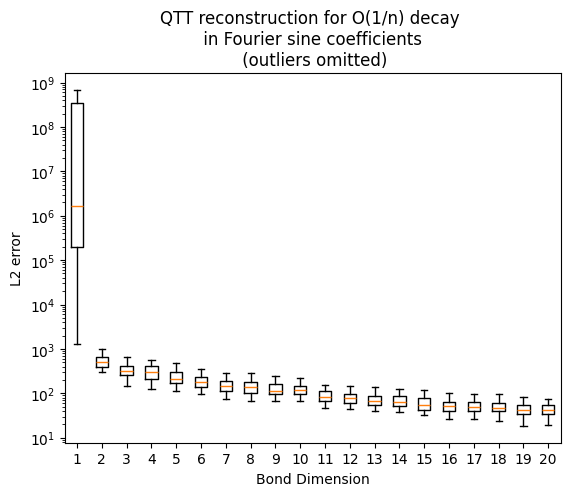

In [11]:
plt.boxplot(order1_l2_error, showfliers=False)
plt.title('QTT reconstruction for O(1/n) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

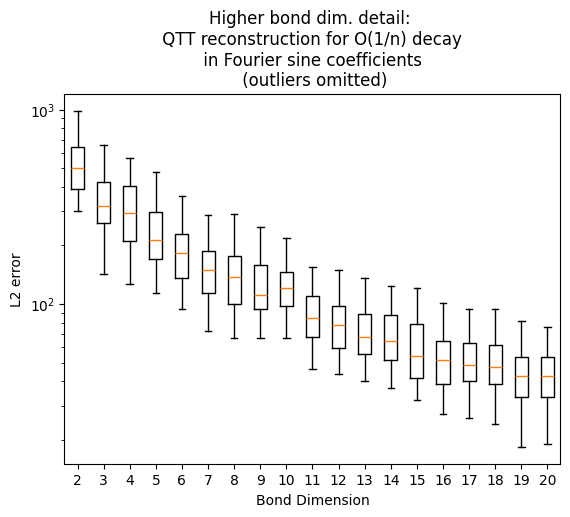

In [12]:
plt.boxplot(order1_l2_error[:, 1:], tick_labels=labels[1:], showfliers=False)
plt.title('Higher bond dim. detail: \n QTT reconstruction for O(1/n) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

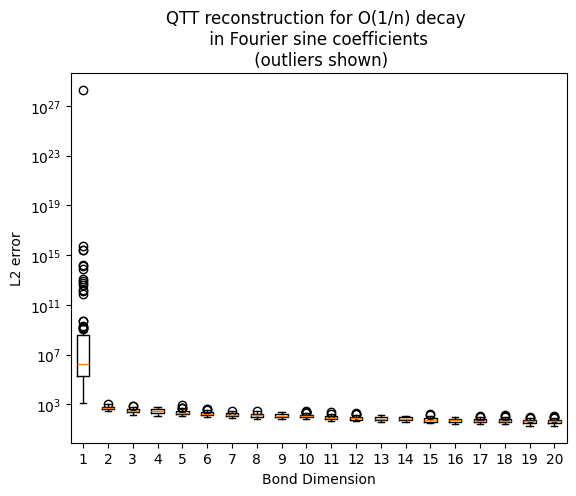

In [13]:
plt.boxplot(order1_l2_error, showfliers=True)
plt.title('QTT reconstruction for O(1/n) decay \n in Fourier sine coefficients \n (outliers shown)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

### $O(1/n^2)$ decay, QTT resolution = $2^{10}$, 100 runs

In [14]:
order2_l2_error = run_for_given_order(order=2, bondDims=20)

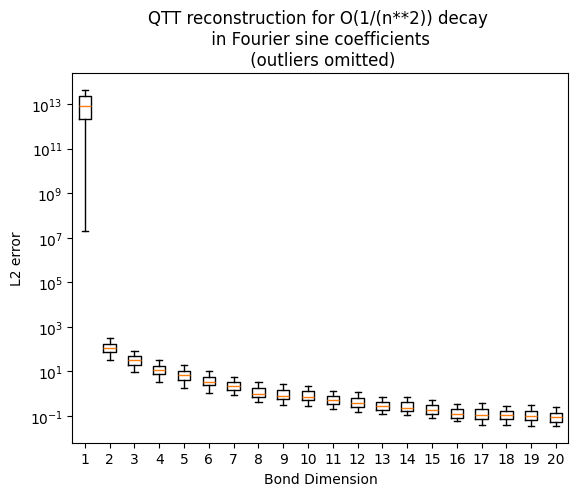

In [15]:
plt.boxplot(order2_l2_error, showfliers=False)
plt.title('QTT reconstruction for O(1/(n**2)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

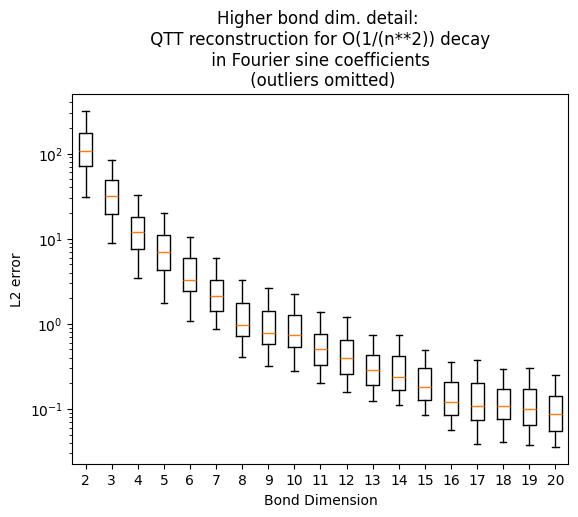

In [16]:
plt.boxplot(order2_l2_error[:, 1:], tick_labels=labels[1:], showfliers=False)
plt.title('Higher bond dim. detail: \n QTT reconstruction for O(1/(n**2)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

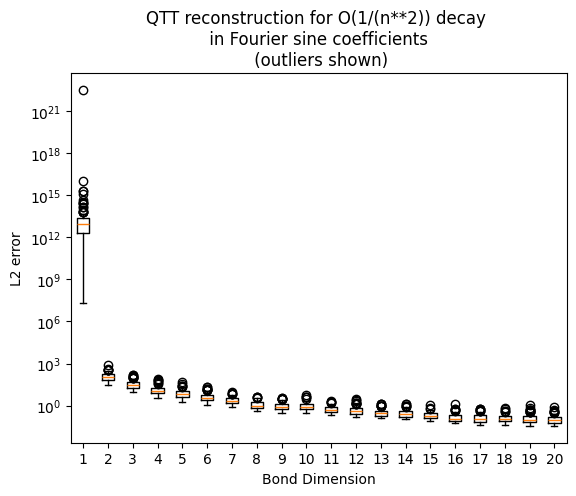

In [17]:
plt.boxplot(order2_l2_error, showfliers=True)
plt.title('QTT reconstruction for O(1/(n**2)) decay \n in Fourier sine coefficients \n (outliers shown)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

### $O(1/n^3)$ decay, QTT resolution = $2^{10}$, 100 runs

In [18]:
order3_l2_error = run_for_given_order(order=3, bondDims=20)

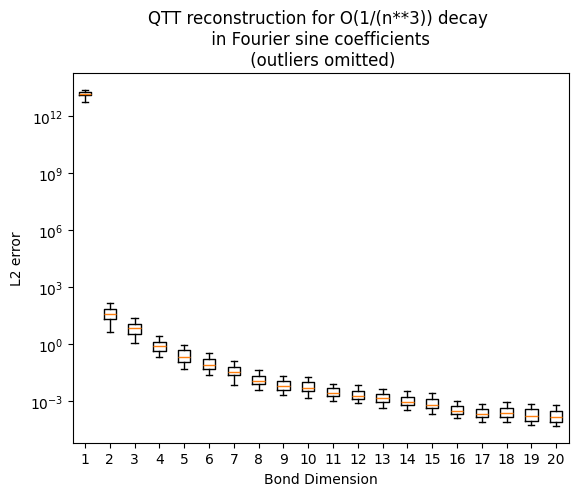

In [19]:
plt.boxplot(order3_l2_error, showfliers=False)
plt.title('QTT reconstruction for O(1/(n**3)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

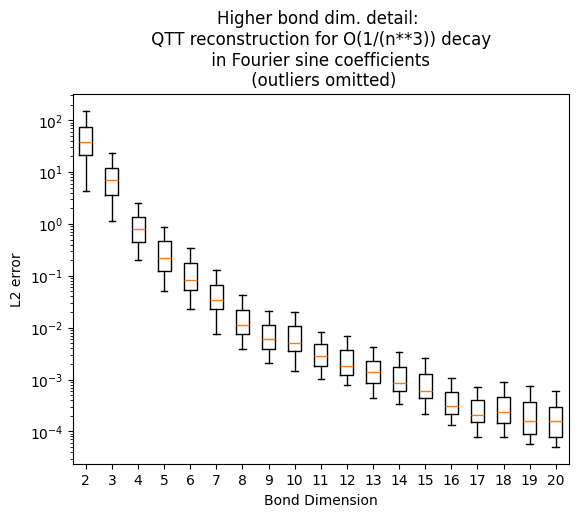

In [20]:
plt.boxplot(order3_l2_error[:, 1:], tick_labels=labels[1:], showfliers=False)
plt.title('Higher bond dim. detail: \n QTT reconstruction for O(1/(n**3)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

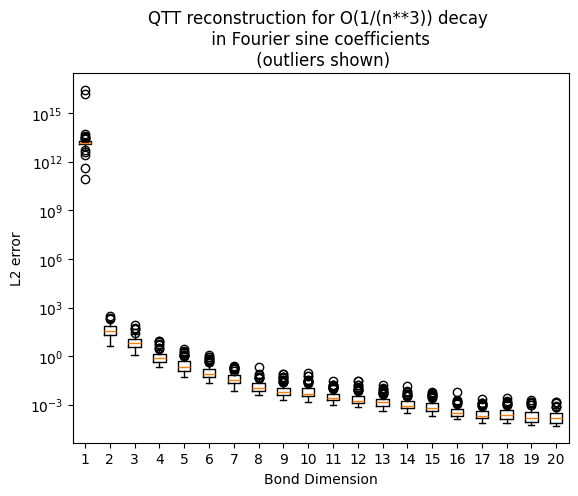

In [21]:
plt.boxplot(order3_l2_error, showfliers=True)
plt.title('QTT reconstruction for O(1/(n**3)) decay \n in Fourier sine coefficients \n (outliers shown)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

### $O(1/n^4)$ decay, QTT resolution = $2^{10}$, 100 runs

In [22]:
order4_l2_error = run_for_given_order(order=4, bondDims=20)

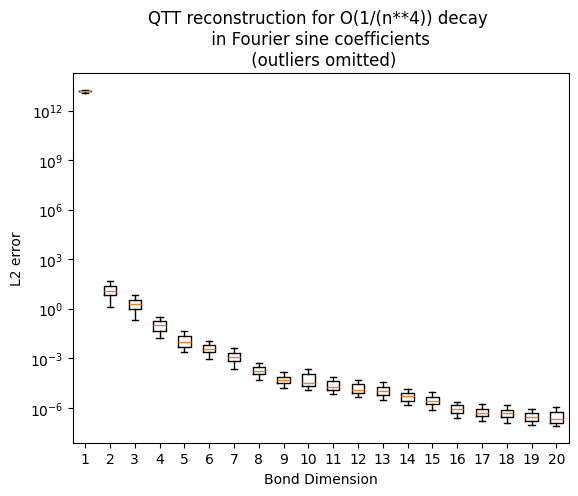

In [23]:
plt.boxplot(order4_l2_error, showfliers=False)
plt.title('QTT reconstruction for O(1/(n**4)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

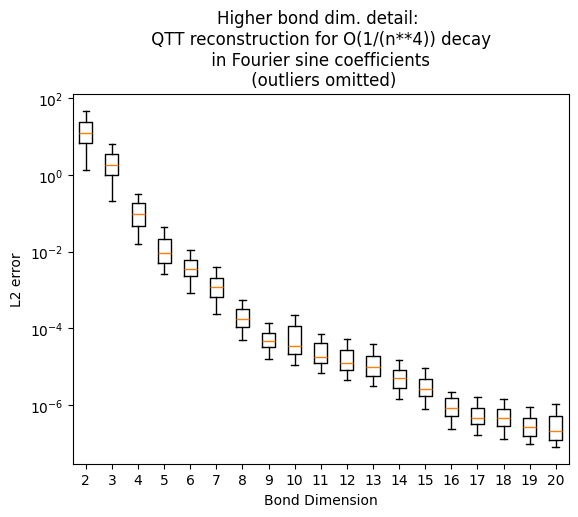

In [24]:
plt.boxplot(order4_l2_error[:, 1:], tick_labels=labels[1:], showfliers=False)
plt.title('Higher bond dim. detail: \n QTT reconstruction for O(1/(n**4)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

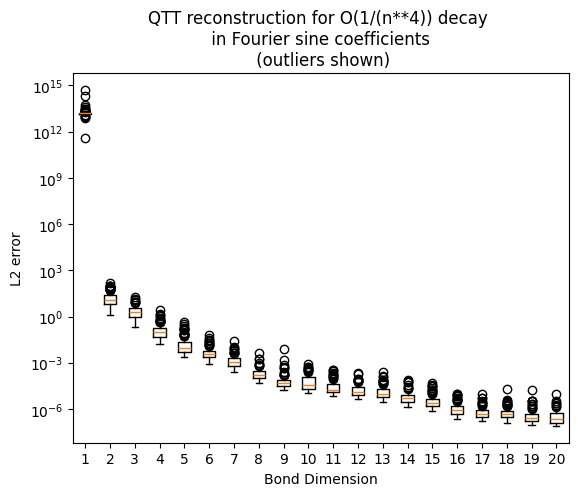

In [25]:
plt.boxplot(order4_l2_error, showfliers=True)
plt.title('QTT reconstruction for O(1/(n**4)) decay \n in Fourier sine coefficients \n (outliers shown)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

### $O(1/n^5)$ decay, QTT resolution = $2^{10}$, 100 runs

In [26]:
order5_l2_error = run_for_given_order(order=5, bondDims=20)

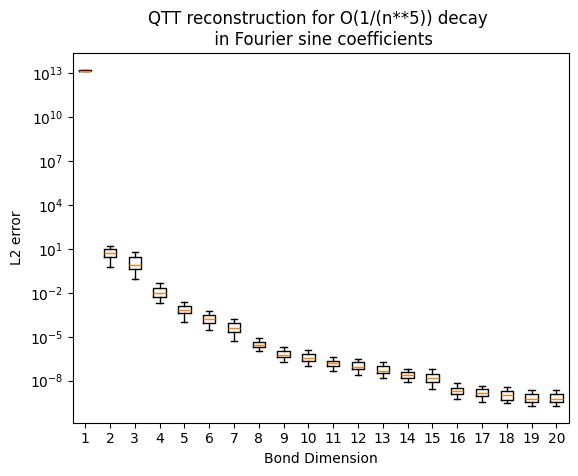

In [27]:
plt.boxplot(order5_l2_error, showfliers=False)
plt.title('QTT reconstruction for O(1/(n**5)) decay \n in Fourier sine coefficients')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

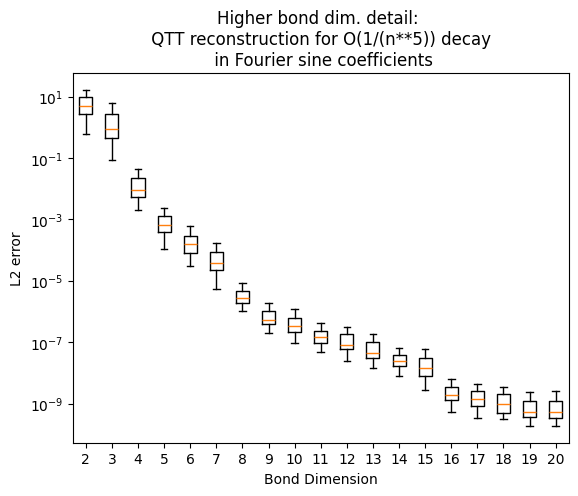

In [28]:
plt.boxplot(order5_l2_error[:, 1:], tick_labels=labels[1:], showfliers=False)
plt.title('Higher bond dim. detail: \n QTT reconstruction for O(1/(n**5)) decay \n in Fourier sine coefficients')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

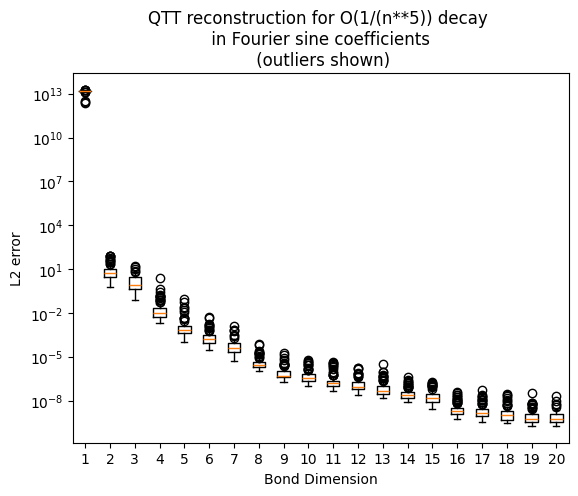

In [29]:
plt.boxplot(order5_l2_error, showfliers=True)
plt.title('QTT reconstruction for O(1/(n**5)) decay \n in Fourier sine coefficients \n (outliers shown)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

### $O(1/n^6)$ decay, QTT resolution = $2^{10}$, 100 runs

In [30]:
order6_l2_error = run_for_given_order(order=6, bondDims=20)

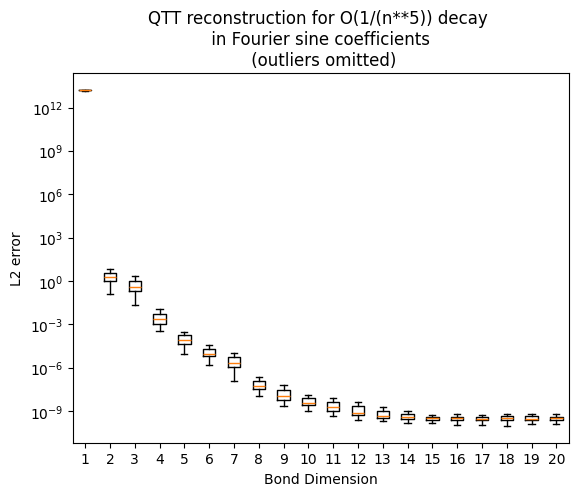

In [31]:
plt.boxplot(order6_l2_error, showfliers=False)
plt.title('QTT reconstruction for O(1/(n**5)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

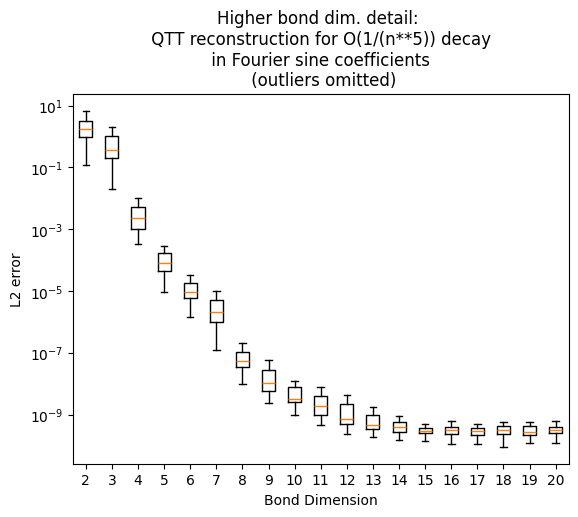

In [32]:
plt.boxplot(order6_l2_error[:, 1:], tick_labels=labels[1:], showfliers=False)
plt.title('Higher bond dim. detail: \n QTT reconstruction for O(1/(n**5)) decay \n in Fourier sine coefficients \n (outliers omitted)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()

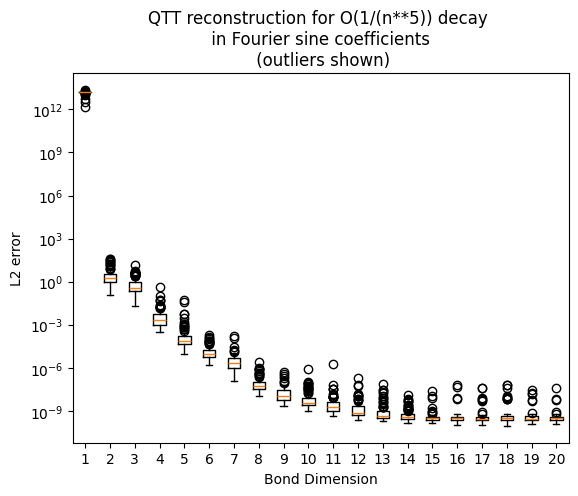

In [33]:
plt.boxplot(order6_l2_error, showfliers=True)
plt.title('QTT reconstruction for O(1/(n**5)) decay \n in Fourier sine coefficients \n (outliers shown)')
plt.xlabel('Bond Dimension')
plt.ylabel('L2 error')
plt.yscale('log')
plt.show()